In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data\\processed\\thien3703_rapid_games_processed_1.csv', index_col=0)
print(f'Shape: {df.shape}')


Shape: (1286, 15)


In [20]:
df

,start_time,end_time,time_control,rated,opening_type,opening,opening_family,num_moves,avg_time_per_move,player_color,player_rating,opponent_rating,player_result,result_method,rating_change
0,2025-01-02 05:55:56,2025-01-02 06:01:32,600,True,A00,Mieses Opening,Mieses Opening,63,3.683871,black,1093,1374,Loss,Abandon,0
1,2025-02-10 05:23:10,2025-02-10 05:31:45,600,True,D00,Queens Pawn Opening 1...d5 2.e3,Queens Pawn Opening,39,12.436842,white,1217,1078,Win,Resign,124
2,2025-02-10 05:31:58,2025-02-10 05:44:51,600,True,C00,French Defense Knight Variation,French Defense,70,4.367647,black,1308,1202,Win,Resign,91
3,2025-02-14 05:37:00,2025-02-14 05:50:33,600,True,B20,Sicilian Defense 2.d3,Sicilian Defense,75,10.664865,white,1383,1306,Win,Resign,75
4,2025-02-14 05:50:45,2025-02-14 06:00:07,600,True,D31,Queens Gambit Declined Queens Knight Variation...,Queens Gambit,45,10.768182,black,1308,1316,Loss,Checkmate,-75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,2026-06-17 14:02:53,2026-06-17 14:06:49,600,True,C30,Kings Gambit,Kings Gambit,45,5.281818,black,1573,1586,Loss,Checkmate,-8
1282,2026-06-17 14:06:53,2026-06-17 14:19:35,600,True,B44,Sicilian Defense Taimanov Variation 5.Nxc6 bxc6,Sicilian Defense,114,6.333929,white,1565,1596,Loss,Checkmate,-8
1283,2026-06-17 14:20:21,2026-06-17 14:29:10,600,True,D00,Queens Pawn Opening Accelerated London System,Queens Pawn Opening,51,10.684000,black,1557,1563,Loss,Checkmate,-8
1284,2026-06-19 06:07:38,2026-06-19 06:16:57,600,True,C44,Ponziani Opening Jaenisch Breyer Opening 4...d5,Ponziani Opening,71,8.922857,white,1565,1562,Win,Abandon,8


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   start_time         1286 non-null   str    
 1   end_time           1286 non-null   str    
 2   time_control       1286 non-null   str    
 3   rated              1286 non-null   bool   
 4   opening_type       1286 non-null   str    
 5   opening            1286 non-null   str    
 6   opening_family     1286 non-null   str    
 7   num_moves          1286 non-null   int64  
 8   avg_time_per_move  1286 non-null   float64
 9   player_color       1286 non-null   str    
 10  player_rating      1286 non-null   int64  
 11  opponent_rating    1286 non-null   int64  
 12  player_result      1286 non-null   str    
 13  result_method      1286 non-null   str    
 14  rating_change      1286 non-null   int64  
dtypes: bool(1), float64(1), int64(4), str(9)
memory usage: 142.0 KB


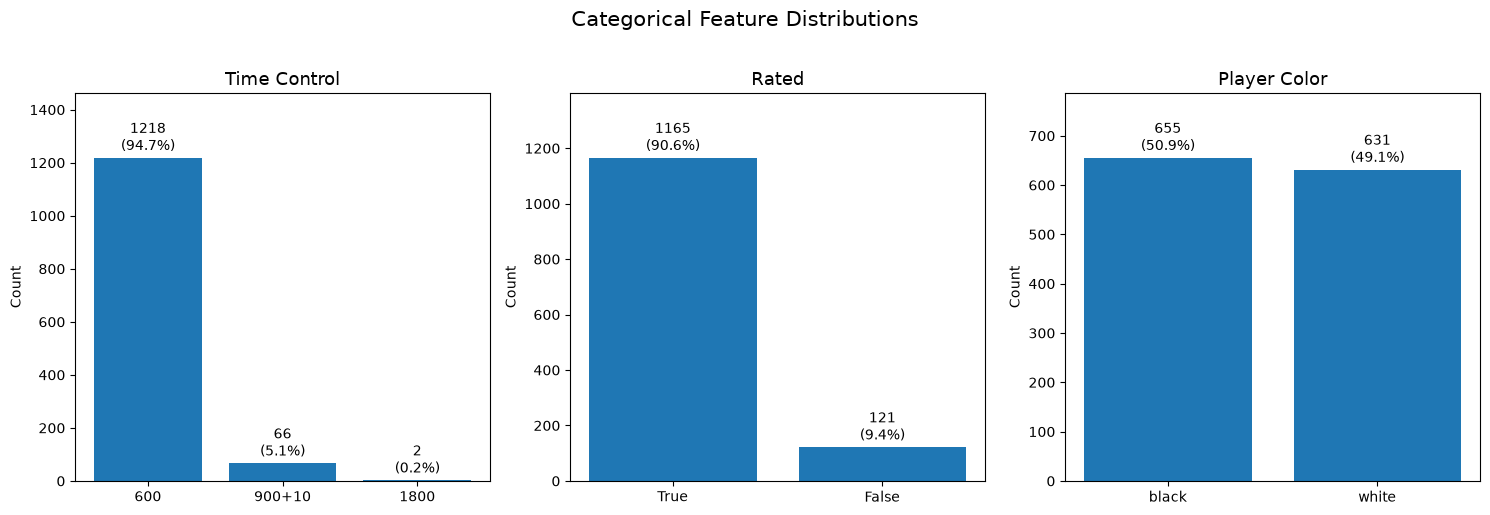

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cols = ['time_control', 'rated', 'player_color']
titles = ['Time Control', 'Rated', 'Player Color']

for ax, col, title in zip(axes, cols, titles):
    counts = df[col].value_counts()
    percentages = counts / counts.sum() * 100

    bars = ax.bar(counts.index.astype(str), counts.values)

    for bar, count, pct in zip(bars, counts.values, percentages.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


In [24]:
for col in df.columns:
    if ('opening' in col):
        print(f"Number of distinct values in {col} column: {df[col].nunique()}")
# Extract the first letter of opening type and remove all available opening-related columns 

Number of distinct values in opening_type column: 110
Number of distinct values in opening column: 517
Number of distinct values in opening_family column: 52


In [25]:
df[['num_moves', 'avg_time_per_move']].describe().T
#avg_time_per_move has got negative values (anomaly)

,count,mean,std,min,25%,50%,75%,max
num_moves,1286.0,75.232504,35.225317,3.00000,49.250000,71.000000,97.000000,217.000000
avg_time_per_move,1286.0,9.607806,4.057146,-2.94375,6.716449,9.275185,12.076477,32.868421


In [39]:
df[['player_rating', 'opponent_rating']].describe().T

,count,mean,std,min,25%,50%,75%,max
player_rating,1286.0,1360.105754,133.287331,1093.0,1239.25,1341.5,1492.0,1617.0
opponent_rating,1286.0,1358.200622,164.337032,246.0,1234.25,1343.0,1492.0,2140.0


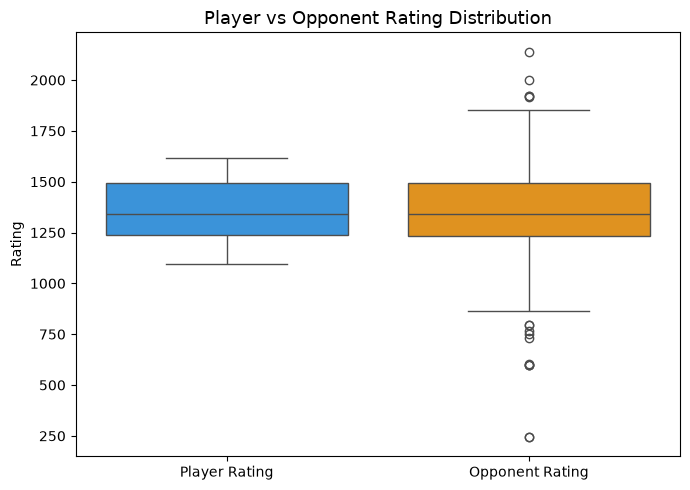

In [38]:
fig, ax = plt.subplots(figsize=(7, 5))

plot_df = df[['player_rating', 'opponent_rating']].melt(var_name='Type', value_name='Rating')
plot_df['Type'] = plot_df['Type'].map({'player_rating': 'Player Rating', 'opponent_rating': 'Opponent Rating'})

sns.boxplot(data=plot_df, x='Type', y='Rating', hue='Type', palette=['#2196F3', '#FF9800'], legend=False, ax=ax)

ax.set_title('Player vs Opponent Rating Distribution', fontsize=13)
ax.set_xlabel('')
plt.tight_layout()
plt.show()


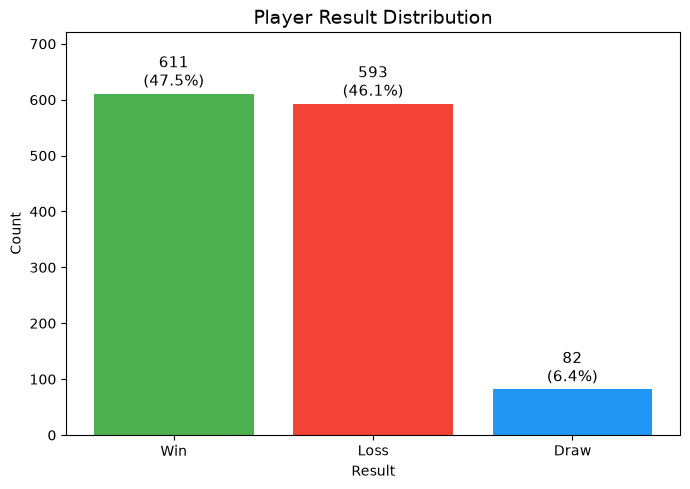

In [ ]:
counts = df['player_result'].value_counts()
percentages = df['player_result'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values, color=['#4CAF50', '#F44336', '#2196F3'])

for bar, count, pct in zip(bars, counts.values, percentages.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Player Result Distribution', fontsize=14)
ax.set_xlabel('Result')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()


In [29]:
# Game time: end - start
# Split starting time to 3-hour bins
# Extract the first letter of opening type
# Rating difference between two players
# Bin opponent rating into bins
